In [140]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("columbine/imdb-dataset-sentiment-analysis-in-csv-format")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-sentiment-analysis-in-csv-format' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-sentiment-analysis-in-csv-format


In [141]:
import os

print(os.listdir(path))

['Valid.csv', 'Train.csv', 'Test.csv']


In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makes plots look better
sns.set_style("whitegrid")

In [143]:
train_df = pd.read_csv(f"{path}/Train.csv")
valid_df = pd.read_csv(f"{path}/Valid.csv")
test_df = pd.read_csv(f"{path}/Test.csv")

In [144]:
train_df.head()

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


In [145]:
train_df.columns

Index(['text', 'label'], dtype='object')

In [146]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    40000 non-null  object
 1   label   40000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 625.1+ KB


In [147]:
train_df.isnull().sum()

,0
text,0
label,0


In [148]:
train_df["label"].value_counts()

,count
label,
0,20019
1,19981


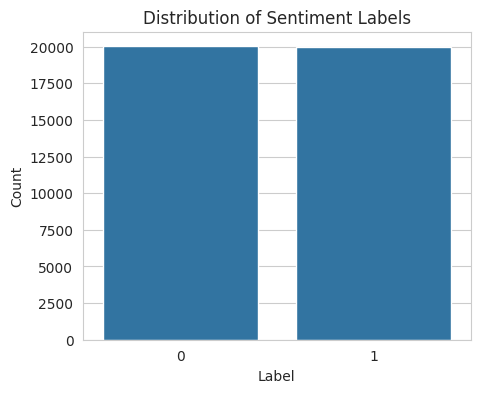

In [149]:
plt.figure(figsize=(5,4))

sns.countplot(data=train_df, x="label")

plt.title("Distribution of Sentiment Labels")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [150]:
print("Label = 0\n")
print(train_df[train_df["label"]==0]["text"].iloc[0])

Label = 0

I grew up (b. 1965) watching and loving the Thunderbirds. All my mates at school watched. We played "Thunderbirds" before school, during lunch and after school. We all wanted to be Virgil or Scott. No one wanted to be Alan. Counting down from 5 became an art form. I took my children to see the movie hoping they would get a glimpse of what I loved as a child. How bitterly disappointing. The only high point was the snappy theme tune. Not that it could compare with the original score of the Thunderbirds. Thankfully early Saturday mornings one television channel still plays reruns of the series Gerry Anderson and his wife created. Jonatha Frakes should hand in his directors chair, his version was completely hopeless. A waste of film. Utter rubbish. A CGI remake may be acceptable but replacing marionettes with Homo sapiens subsp. sapiens was a huge error of judgment.


In [151]:
train_df["review_length"] = train_df["text"].apply(len)

In [152]:
train_df[["text","review_length"]].head()

,text,review_length
0,I grew up (b. 1965) watching and loving the Th...,874
1,"When I put this movie in my DVD player, and sa...",1811
2,Why do people who do not know what a particula...,983
3,Even though I have great interest in Biblical ...,351
4,Im a die hard Dads Army fan and nothing will e...,983


In [153]:
train_df["review_length"].describe()

,review_length
count,40000.000000
mean,1310.293250
std,988.358599
min,32.000000
25%,698.000000
50%,973.000000
75%,1596.000000
max,13704.000000


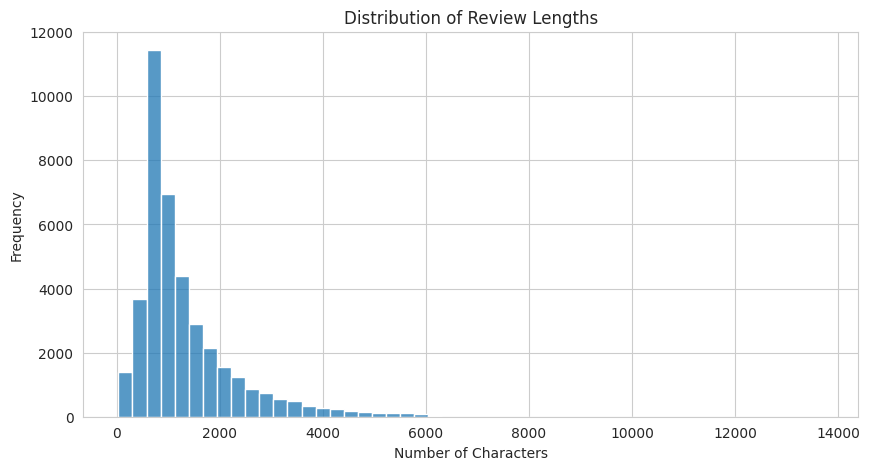

In [154]:
plt.figure(figsize=(10,5))

sns.histplot(train_df["review_length"], bins=50)

plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

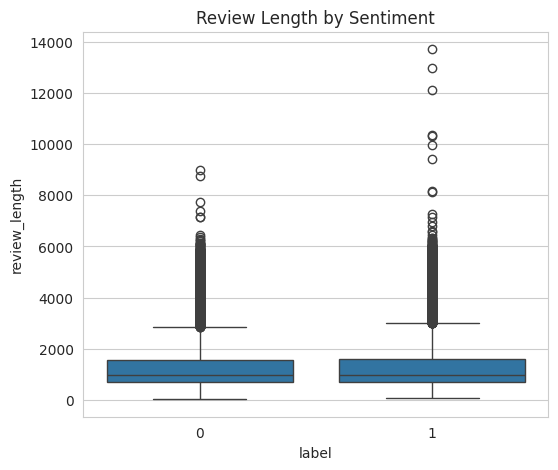

In [155]:
plt.figure(figsize=(6,5))

sns.boxplot(data=train_df,
            x="label",
            y="review_length")

plt.title("Review Length by Sentiment")

plt.show()

In [156]:
train_df.duplicated().sum()

np.int64(277)

In [157]:
print("Training Samples :", len(train_df))
print("Validation Samples :", len(valid_df))
print("Testing Samples :", len(test_df))

print()

print("Missing Values:")
print(train_df.isnull().sum())

print()

print("Duplicates :", train_df.duplicated().sum())

print()

print(train_df["label"].value_counts())

Training Samples : 40000
Validation Samples : 5000
Testing Samples : 5000

Missing Values:
text             0
label            0
review_length    0
dtype: int64

Duplicates : 277

label
0    20019
1    19981
Name: count, dtype: int64


In [158]:
train_df = train_df.drop_duplicates().reset_index(drop=True)

In [159]:
train_df.duplicated().sum()

np.int64(0)

In [160]:
import re
def remove_html(text):
    clean = re.sub(r"<.*?>", "", text)
    return clean

In [161]:
text="<abs>abc"
re.sub(r"<.*?>", "", text)

'abc'

In [162]:
def remove_urls(text):
    pattern = r'https?://\S+|www\.\S+'
    return re.sub(pattern, '', text)

In [163]:
sample = "Amazing movie! Visit https://imdb.com for more details."

print(remove_urls(sample))

Amazing movie! Visit  for more details.


In [164]:
import string
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

In [165]:
import nltk
nltk.download('punkt_tab')
sample = "I absolutely loved this movie."
tokens = word_tokenize(sample)
print(tokens)

['I', 'absolutely', 'loved', 'this', 'movie', '.']


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [166]:
def tokenize_text(text):
    return word_tokenize(text)

In [167]:
sample_review = train_df["text"].iloc[0]

tokens = tokenize_text(sample_review)

print(tokens[:30])

['I', 'grew', 'up', '(', 'b', '.', '1965', ')', 'watching', 'and', 'loving', 'the', 'Thunderbirds', '.', 'All', 'my', 'mates', 'at', 'school', 'watched', '.', 'We', 'played', '``', 'Thunderbirds', "''", 'before', 'school', ',', 'during']


In [168]:
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

print(list(stop_words)[:30])

negation_words = {"not", "no", "nor", "never"}

stop_words = stop_words - negation_words

["you're", 'any', 'ain', 'too', "we've", 'nor', "that'll", 'why', 'up', 'as', "weren't", "he's", 'who', 'won', 'ourselves', "mustn't", 'after', 'wouldn', 'couldn', 'of', "won't", "hadn't", 'which', "he'll", 'll', "haven't", 'those', "you've", "they'll", 'once']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [169]:
def remove_stopwords(text):
    words = word_tokenize(text)

    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)

In [170]:
import nltk

nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger")

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

import nltk

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [171]:
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize

In [172]:
lemmatizer = WordNetLemmatizer()

In [173]:
def get_wordnet_pos(treebank_tag):

    if treebank_tag.startswith('J'):
        return wordnet.ADJ

    elif treebank_tag.startswith('V'):
        return wordnet.VERB

    elif treebank_tag.startswith('N'):
        return wordnet.NOUN

    elif treebank_tag.startswith('R'):
        return wordnet.ADV

    else:
        return wordnet.NOUN

In [174]:
def lemmatize_text(text):

    words = word_tokenize(text)

    tagged_words = pos_tag(words)

    lemmatized_words = []

    for word, tag in tagged_words:

        pos = get_wordnet_pos(tag)

        lemma = lemmatizer.lemmatize(word, pos)

        lemmatized_words.append(lemma)

    return " ".join(lemmatized_words)

In [175]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

sample = "The dogs are running faster than the cats"

print(lemmatize_text(sample))

The dog be run faster than the cat


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [176]:
def remove_numbers(text):
    return re.sub(r"\d+", "", text)

In [177]:
def preprocess_text(text):

    text = text.lower()

    text = remove_html(text)

    text = remove_urls(text)

    text = remove_punctuation(text)

    text = remove_numbers(text)

    text = remove_stopwords(text)

    text = lemmatize_text(text)

    return text

In [178]:
train_df["clean_text"] = train_df["text"].apply(preprocess_text)

valid_df["clean_text"] = valid_df["text"].apply(preprocess_text)

test_df["clean_text"] = test_df["text"].apply(preprocess_text)

In [179]:
train_df.head()

,text,label,review_length,clean_text
0,I grew up (b. 1965) watching and loving the Th...,0,874,grow b watch loving thunderbird mat school wat...
1,"When I put this movie in my DVD player, and sa...",0,1811,put movie dvd player sit coke chip expectation...
2,Why do people who do not know what a particula...,0,983,people not know particular time past like feel...
3,Even though I have great interest in Biblical ...,0,351,even though great interest biblical movie bore...
4,Im a die hard Dads Army fan and nothing will e...,1,983,im die hard dad army fan nothing ever change g...


In [180]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [181]:
tfidf = TfidfVectorizer(
    max_features=5000
)

In [182]:
X_train = tfidf.fit_transform(train_df["clean_text"])

In [183]:
X_valid = tfidf.transform(valid_df["clean_text"])
X_test = tfidf.transform(test_df["clean_text"])

In [184]:
y_train = train_df["label"]
y_valid = valid_df["label"]
y_test = test_df["label"]

In [185]:
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test :", X_test.shape)

X_train: (39723, 5000)
X_valid: (5000, 5000)
X_test : (5000, 5000)


In [186]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:50])

['aaron' 'abandon' 'abc' 'ability' 'able' 'abortion' 'abraham' 'abrupt'
 'abruptly' 'absence' 'absent' 'absolute' 'absolutely' 'absorb' 'absurd'
 'absurdity' 'abuse' 'abusive' 'abysmal' 'academy' 'accent' 'accept'
 'acceptable' 'acceptance' 'access' 'accident' 'accidentally' 'acclaim'
 'accompany' 'accomplish' 'accord' 'account' 'accuracy' 'accurate'
 'accurately' 'accuse' 'ace' 'achieve' 'achievement' 'acid' 'acknowledge'
 'acquire' 'across' 'act' 'acted' 'acting' 'action' 'active' 'activity'
 'actor']


In [187]:
tfidf_df = pd.DataFrame(
    X_train[:5].toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,aaron,abandon,abc,ability,able,abortion,abraham,abrupt,abruptly,absence,...,young,youngster,youre,youth,youtube,youve,zero,zombie,zone,zoom
0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.076117,0.0,0.0,0.0,0.0,0.113074,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.345037,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


In [189]:
feature_names = tfidf.get_feature_names_out()

first_review = X_train[0].toarray().flatten()

indices = first_review.argsort()[-10:][::-1]

for i in indices:
    print(feature_names[i], ":", first_review[i])

school : 0.3194892418734634
child : 0.19713195253906282
lunch : 0.1857868717675524
judgment : 0.1845102953243632
hopeless : 0.17952244186886068
acceptable : 0.16863767574377916
anderson : 0.16627082159570486
error : 0.16398123741393117
chair : 0.16307305244446046
thankfully : 0.15865978753348492


In [190]:
from sklearn.naive_bayes import MultinomialNB

In [191]:
nb_model = MultinomialNB()

In [192]:
nb_model.fit(X_train, y_train)

MultinomialNB()

In [193]:
y_pred = nb_model.predict(X_valid)

In [194]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [195]:
print("Accuracy :", accuracy_score(y_valid, y_pred))
print("Precision:", precision_score(y_valid, y_pred))
print("Recall   :", recall_score(y_valid, y_pred))
print("F1 Score :", f1_score(y_valid, y_pred))

Accuracy : 0.8454
Precision: 0.8399062866067942
Recall   : 0.8556085918854416
F1 Score : 0.8476847290640394


In [196]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.84      2486
           1       0.84      0.86      0.85      2514

    accuracy                           0.85      5000
   macro avg       0.85      0.85      0.85      5000
weighted avg       0.85      0.85      0.85      5000



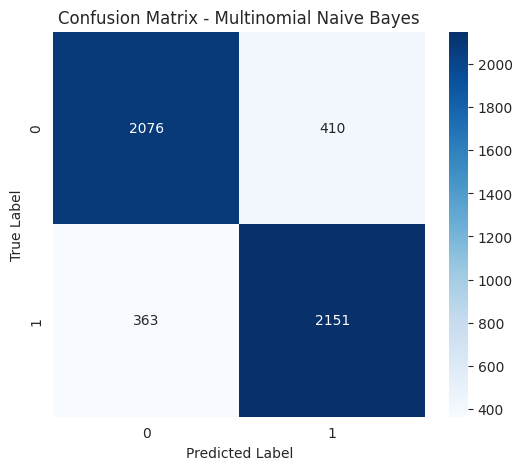

In [197]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [198]:
from sklearn.linear_model import LogisticRegression

In [199]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [200]:
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [201]:
lr_pred = lr_model.predict(X_valid)

In [202]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_valid, lr_pred))
print("Precision:", precision_score(y_valid, lr_pred))
print("Recall   :", recall_score(y_valid, lr_pred))
print("F1 Score :", f1_score(y_valid, lr_pred))

print("\nClassification Report\n")
print(classification_report(y_valid, lr_pred))

Accuracy : 0.8798
Precision: 0.8671785028790787
Recall   : 0.8985680190930787
F1 Score : 0.8825942566907599

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.86      0.88      2486
           1       0.87      0.90      0.88      2514

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



In [203]:
from sklearn.svm import LinearSVC

In [204]:
svm_model = LinearSVC(random_state=42)

In [205]:
svm_model.fit(X_train, y_train)

LinearSVC(random_state=42)

In [208]:
svm_pred = svm_model.predict(X_valid)
print("Accuracy :", accuracy_score(y_valid, svm_pred))
print("Precision:", precision_score(y_valid, svm_pred))
print("Recall   :", recall_score(y_valid, svm_pred))
print("F1 Score :", f1_score(y_valid, svm_pred))

print(classification_report(y_valid, svm_pred))

Accuracy : 0.8804
Precision: 0.8727626459143969
Recall   : 0.8922036595067622
F1 Score : 0.8823760818253343
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      2486
           1       0.87      0.89      0.88      2514

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



In [209]:
import pickle

In [210]:
import joblib

In [211]:
joblib.dump(
    lr_model,
    "sentiment_model.pkl"
)

['sentiment_model.pkl']

In [212]:
joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

['tfidf_vectorizer.pkl']

In [213]:
loaded_model = joblib.load(
    "sentiment_model.pkl"
)

loaded_vectorizer = joblib.load(
    "tfidf_vectorizer.pkl"
)

In [214]:
review = """
This movie was absolutely fantastic.
The acting was brilliant and I loved every minute.
"""

In [215]:
clean_review = preprocess_text(review)

In [216]:
review_vector = loaded_vectorizer.transform(
    [clean_review]
)

In [217]:
prediction = loaded_model.predict(
    review_vector
)

print(prediction)

[1]


In [218]:
if prediction[0] == 1:
    print("Positive 😊")
else:
    print("Negative 😔")

Positive 😊
